<a href="https://colab.research.google.com/github/gulendamarici/Netflix-project/blob/main/Bilgisayar_Tabanl%C4%B1_%C3%96%C4%9Frenen_Sistemler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from keras.datasets import reuters
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer


# ----------------------------
#  Veri hazırlığı
# ----------------------------
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Kelime indekslerini metne çevir
word_index = reuters.get_word_index()
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

def decode_review(seq):
    return " ".join(index_word.get(i, "?") for i in seq)

x_train_text = [decode_review(x) for x in x_train]
x_test_text  = [decode_review(x) for x in x_test]

# CCAT topic listesi
CCAT_LIKE_TOPICS = {3, 35, 36, 42, 43, 44, 45}

# Binary etiketler
y_train_bin = np.array([1 if y in CCAT_LIKE_TOPICS else 0 for y in y_train])
y_test_bin  = np.array([1 if y in CCAT_LIKE_TOPICS else 0 for y in y_test])

# ----------------------------
# TF-IDF Vektörleştirme
# ----------------------------
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(x_train_text)
X_test_tfidf  = vectorizer.transform(x_test_text)


X_train_dense = X_train_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()


In [33]:
# 1) Gerekli importlar
import numpy as np
from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

# 2) Reuters dataseti indirildi
# num_words=10000 demek: en sık geçen 10.000 kelime kullanıldı
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

print("Train örnek sayısı:", len(x_train))
print("Test örnek sayısı :", len(x_test))

# 3) Sayılardan kelimeye çeviri sözlüğü (decode için)
word_index = reuters.get_word_index()
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

def decode(seq):
    return " ".join(index_word.get(i, "?") for i in seq)

# 4) Her haberi gerçek metne çevirir
x_train_text = [decode(x) for x in x_train]
x_test_text  = [decode(x) for x in x_test]

print("Örnek metin:", x_train_text[0][:200], "...")

# 5) CCAT benzeri sınıfları 1 yap, diğerlerini 0 yap
CCAT_LIKE_TOPICS = {3, 35, 36, 42, 43, 44, 45}

y_train_bin = np.array([1 if y in CCAT_LIKE_TOPICS else 0 for y in y_train], dtype=np.int32)
y_test_bin  = np.array([1 if y in CCAT_LIKE_TOPICS else 0 for y in y_test], dtype=np.int32)

print("Train sınıf dağılımı:", np.unique(y_train_bin, return_counts=True))
print("Test  sınıf dağılımı:", np.unique(y_test_bin, return_counts=True))

# 6) TF-IDF (metni sayılara çeviren adım)
# ngram_range=(1,2): tek kelime + iki kelimelik ifadeler de dahil
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(x_train_text)  # sparse CSR matrix
X_test_tfidf  = vectorizer.transform(x_test_text)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf  shape:", X_test_tfidf.shape)
print("Sparse mi? ", sparse.issparse(X_train_tfidf))

# 7) KAYDET: SVM için sparse lazım (bellek şişmesin diye DENSE yapmıyoruz)
sparse.save_npz("reuters_tfidf_train.npz", X_train_tfidf)
sparse.save_npz("reuters_tfidf_test.npz", X_test_tfidf)
np.save("reuters_y_train.npy", y_train_bin)
np.save("reuters_y_test.npy", y_test_bin)

print(" Kaydedildi: reuters_tfidf_train.npz, reuters_tfidf_test.npz, reuters_y_train.npy, reuters_y_test.npy")


Train örnek sayısı: 8982
Test örnek sayısı : 2246
Örnek metin: <START> <UNK> <UNK> said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net sho ...
Train sınıf dağılımı: (array([0, 1], dtype=int32), array([5700, 3282]))
Test  sınıf dağılımı: (array([0, 1], dtype=int32), array([1401,  845]))
X_train_tfidf shape: (8982, 10000)
X_test_tfidf  shape: (2246, 10000)
Sparse mi?  True
 Kaydedildi: reuters_tfidf_train.npz, reuters_tfidf_test.npz, reuters_y_train.npy, reuters_y_test.npy


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_higgs_subset(total_samples=20000, test_size=0.2, random_state=42):
    """
    UCI Repository'den HIGGS veri setini stream ederek okur,
    belirtilen sayıda alt küme oluşturur ve  normalize eder.
    """

    # UCI HIGGS Veri Seti URL'i (Gzip formatında)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"

    print(f"1. HIGGS veri seti UCI sunucusundan okunuyor...")
    print("   (Not: Dosyanın tamamı indirilmiyor, sadece gerekli kısım çekiliyor. Lütfen bekleyiniz...)")


    # nrows=total_samples * 1.2 diyerek biraz fazlasını alıyoruz ki karıştırınca (shuffle) denge bozulmasın.
    try:
        # HIGGS veri setinde başlık (header) yoktur.
        # 1. Kolon: Sınıf Etiketi (1.0 = Sinyal, 0.0 = Arkaplan)
        # 2-29. Kolonlar: 28 adet öznitelik (21 düşük seviye, 7 yüksek seviye fiziksel özellik)
        raw_df = pd.read_csv(url, compression='gzip', header=None, nrows=int(total_samples * 1.5))
    except Exception as e:
        print(f"Hata: Veri çekilemedi. İnternet bağlantınızı kontrol edin.\nDetay: {e}")
        return None, None, None, None

    # Veriyi Numpya çevirme
    data = raw_df.to_numpy()

    # X (Öznitelikler) ve y (Etiketler) ayrımı
    # İlk sütun etiket (y), geri kalanı özelliklerdir (X)
    y_raw = data[:, 0].astype(int)
    X_raw = data[:, 1:]

    print(f"   Ham veri çekildi: {X_raw.shape}")

    # 2. ÖRNEKLEM SEÇİMİ (Stratified Subsampling)
    # Veriyi karıştırıp tam istenilen sayıya düşürelim
    print(f"2. {total_samples} adet örneklem seçiliyor ve karıştırılıyor...")

    # Geçici bir split ile veriyi hem karıştırıyoruz hem de boyutunu ayarlıyoruz.
    # stratify=y_raw sayesinde sınıf dengesi (Sinyal/Arkaplan oranı) korunur.
    X_subset, _, y_subset, _ = train_test_split(
        X_raw, y_raw,
        train_size=total_samples,
        stratify=y_raw,
        random_state=random_state
    )

    # 3. NORMALİZASYON (MLP İÇİN ÇOK KRİTİK ADIM)
    # Sigmoid/Tanh gibi aktivasyon fonksiyonlarının doyuma ulaşmaması (vanishing gradient)
    # için verilerin ortalaması 0, varyansı 1 olacak şekilde ölçeklenmesi şarttır.
    print("3. Veri normalize ediliyor (StandardScaler)...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    # 4. EĞİTİM VE TEST AYRIMI
    print(f"4. Eğitim ve Test setlerine ayrılıyor (%{100*(1-test_size)} - %{100*test_size})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_subset,
        test_size=test_size,
        random_state=random_state,
        stratify=y_subset
    )

    # Boyut düzeltmeleri (Scratch kodlarda vektör hatalarını önlemek için)
    # y vektörünü (N,) yerine (N, 1) yapmak bazen matris çarpımlarında hayat kurtarır.
    # İsteğe bağlıdır, ancak öğrenciler için açık olması iyidir.
    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    print("\n--- HAZIRLIK TAMAMLANDI ---")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"Sınıf Dağılımı (Train): {np.unique(y_train, return_counts=True)}")
    print("-" * 30)

    return X_train, X_test, y_train, y_test

# --- KULLANIM ---
if __name__ == "__main__":
    X_train, X_test, y_train, y_test = prepare_higgs_subset()

    # ÖĞRENCİLERE VERİLECEK İPUÇLARI:
    print("\n[İPUCU - MLP MODELİ İÇİN]")
    print("1. Giriş Katmanı Boyutu (Input Layer): 28 nöron")
    print("2. Çıkış Katmanı (Output Layer): 1 nöron (Sigmoid aktivasyonu ile 0-1 arası olasılık)")
    print("3. Loss Fonksiyonu: Binary Cross Entropy")
    print("4. Veri StandardScaler ile ölçeklendiği için 'Xavier' veya 'He' initialization kullanmanız önerilir.")

1. HIGGS veri seti UCI sunucusundan okunuyor...
   (Not: Dosyanın tamamı indirilmiyor, sadece gerekli kısım çekiliyor. Lütfen bekleyiniz...)
   Ham veri çekildi: (30000, 28)
2. 20000 adet örneklem seçiliyor ve karıştırılıyor...
3. Veri normalize ediliyor (StandardScaler)...
4. Eğitim ve Test setlerine ayrılıyor (%80.0 - %20.0)...

--- HAZIRLIK TAMAMLANDI ---
X_train shape: (16000, 28)
y_train shape: (16000, 1)
Sınıf Dağılımı (Train): (array([0, 1]), array([7583, 8417]))
------------------------------

[İPUCU - MLP MODELİ İÇİN]
1. Giriş Katmanı Boyutu (Input Layer): 28 nöron
2. Çıkış Katmanı (Output Layer): 1 nöron (Sigmoid aktivasyonu ile 0-1 arası olasılık)
3. Loss Fonksiyonu: Binary Cross Entropy
4. Veri StandardScaler ile ölçeklendiği için 'Xavier' veya 'He' initialization kullanmanız önerilir.


In [10]:
import numpy as np
from scipy import sparse
from sklearn.model_selection import train_test_split

# Dosyalardan yüklendi
X_reu_full = sparse.load_npz("reuters_tfidf_train.npz")  # (8982, 10000) sparse
y_reu_full = np.load("reuters_y_train.npy")             # (8982,) 0/1

# Train -> Train/Val ayırıldı
X_reu_train_svm, X_reu_val_svm, y_reu_train, y_reu_val = train_test_split(
    X_reu_full, y_reu_full,
    test_size=0.2, random_state=42, stratify=y_reu_full
)

# MLP için dense
X_reu_train_mlp = X_reu_train_svm.toarray()
X_reu_val_mlp   = X_reu_val_svm.toarray()

print("REUTERS (SVM sparse) train:", X_reu_train_svm.shape, "val:", X_reu_val_svm.shape, "sparse?", sparse.issparse(X_reu_train_svm))
print("REUTERS (MLP dense)  train:", X_reu_train_mlp.shape, "val:", X_reu_val_mlp.shape)
print("y train dağılım:", np.unique(y_reu_train, return_counts=True))
print("y val   dağılım:", np.unique(y_reu_val, return_counts=True))


REUTERS (SVM sparse) train: (7185, 10000) val: (1797, 10000) sparse? True
REUTERS (MLP dense)  train: (7185, 10000) val: (1797, 10000)
y train dağılım: (array([0, 1], dtype=int32), array([4560, 2625]))
y val   dağılım: (array([0, 1], dtype=int32), array([1140,  657]))


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# y_train zaten (16000,1) idi -> flatten
y_h_train_full = y_train.reshape(-1)
y_h_test = y_test.reshape(-1)

# X_train'i train/val ayrıldı
X_h_train_raw, X_h_val_raw, y_h_train, y_h_val = train_test_split(
    X_train, y_h_train_full,
    test_size=0.2, random_state=42, stratify=y_h_train_full
)

# scaler sadece TRAIN ile fit
scaler_h = StandardScaler()
X_h_train = scaler_h.fit_transform(X_h_train_raw)
X_h_val   = scaler_h.transform(X_h_val_raw)
X_h_test  = scaler_h.transform(X_test)   # test de transform

print("HIGGS train:", X_h_train.shape, "val:", X_h_val.shape, "test:", X_h_test.shape)
print("y train dağılım:", np.unique(y_h_train, return_counts=True))
print("y val   dağılım:", np.unique(y_h_val, return_counts=True))
print("y test  dağılım:", np.unique(y_h_test, return_counts=True))


HIGGS train: (12800, 28) val: (3200, 28) test: (4000, 28)
y train dağılım: (array([0, 1]), array([6066, 6734]))
y val   dağılım: (array([0, 1]), array([1517, 1683]))
y test  dağılım: (array([0, 1]), array([1896, 2104]))


In [32]:
import numpy as np

def binary_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int).reshape(-1)
    y_pred = np.array(y_pred).astype(int).reshape(-1)

    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))

    acc = (tp+tn) / max((tp+tn+fp+fn), 1)
    precision = tp / max((tp+fp), 1)
    recall = tp / max((tp+fn), 1)
    f1 = 0 if (precision+recall)==0 else 2*precision*recall/(precision+recall)

    cm = np.array([[tn, fp],
                   [fn, tp]])
    return acc, f1, cm

print(" Metrik fonksiyonu hazır")


 Metrik fonksiyonu hazır


In [13]:
import numpy as np
from scipy import sparse

class PegasosSVM:
    """
    Pegasos SVM (Primal Estimated sub-GrAdient SOlver)
    - Hinge Loss
    - L2 Regularization
    - Dense ve Sparse destekli
    """

    def __init__(self, lambda_reg=1e-4, epochs=5, batch_size=256, seed=42):
        self.lambda_reg = lambda_reg
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.w = None

    def fit(self, X, y):
        """
        X: dense (np.array) veya sparse (csr_matrix)
        y: {-1, +1}
        """
        rng = np.random.default_rng(self.seed)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)

        t = 0
        is_sparse = sparse.issparse(X)

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                t += 1
                eta = 1.0 / (self.lambda_reg * t)
                batch_idx = indices[start:start+self.batch_size]

                # weight decay
                self.w *= (1 - eta * self.lambda_reg)

                for i in batch_idx:
                    if is_sparse:
                        xi = X[i]
                        margin = y[i] * (xi.dot(self.w))
                        if margin < 1:
                            self.w[xi.indices] += (eta * y[i] / len(batch_idx)) * xi.data
                    else:
                        xi = X[i]
                        margin = y[i] * (np.dot(xi, self.w))
                        if margin < 1:
                            self.w += (eta * y[i] / len(batch_idx)) * xi

                # projection
                norm_w = np.linalg.norm(self.w)
                bound = 1.0 / np.sqrt(self.lambda_reg)
                if norm_w > bound:
                    self.w *= (bound / norm_w)

            print(f"Epoch {epoch+1}/{self.epochs} tamamlandı")

        return self

    def decision_function(self, X):
        return X.dot(self.w) if sparse.issparse(X) else np.dot(X, self.w)

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)


In [14]:
# HIGGS etiketleri {-1, +1}
y_h_train_svm = np.where(y_h_train == 1, 1, -1)
y_h_val_svm   = np.where(y_h_val   == 1, 1, -1)
y_h_test_svm  = np.where(y_h_test  == 1, 1, -1)

svm_higgs = PegasosSVM(lambda_reg=1e-4, epochs=5, batch_size=256)
svm_higgs.fit(X_h_train, y_h_train_svm)

# Validation
y_val_pred = svm_higgs.predict(X_h_val)
acc, f1, cm = binary_metrics(y_h_val_svm, y_val_pred)

print("HIGGS SVM (Validation)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


Epoch 1/5 tamamlandı
Epoch 2/5 tamamlandı
Epoch 3/5 tamamlandı
Epoch 4/5 tamamlandı
Epoch 5/5 tamamlandı
HIGGS SVM (Validation)
Accuracy: 1.0
F1-score: 1.0
Confusion Matrix:
 [[  0   0]
 [  0 994]]


In [15]:
# Reuters etiketleri {-1, +1}
y_reu_train_svm = np.where(y_reu_train == 1, 1, -1)
y_reu_val_svm   = np.where(y_reu_val   == 1, 1, -1)

svm_reuters = PegasosSVM(lambda_reg=1e-4, epochs=5, batch_size=256)
svm_reuters.fit(X_reu_train_svm, y_reu_train_svm)

# Validation
y_val_pred = svm_reuters.predict(X_reu_val_svm)
acc, f1, cm = binary_metrics(y_reu_val_svm, y_val_pred)

print("REUTERS SVM (Validation)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


Epoch 1/5 tamamlandı
Epoch 2/5 tamamlandı
Epoch 3/5 tamamlandı
Epoch 4/5 tamamlandı
Epoch 5/5 tamamlandı
REUTERS SVM (Validation)
Accuracy: 1.0
F1-score: 1.0
Confusion Matrix:
 [[  0   0]
 [  0 583]]


In [16]:
svm_higgs = PegasosSVM(lambda_reg=1e-3, epochs=15, batch_size=128)
svm_higgs.fit(X_h_train, y_h_train_svm)

y_val_pred = svm_higgs.predict(X_h_val)
acc, f1, cm = binary_metrics(y_h_val_svm, y_val_pred)

print("HIGGS SVM (Validation - tuned)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


Epoch 1/15 tamamlandı
Epoch 2/15 tamamlandı
Epoch 3/15 tamamlandı
Epoch 4/15 tamamlandı
Epoch 5/15 tamamlandı
Epoch 6/15 tamamlandı
Epoch 7/15 tamamlandı
Epoch 8/15 tamamlandı
Epoch 9/15 tamamlandı
Epoch 10/15 tamamlandı
Epoch 11/15 tamamlandı
Epoch 12/15 tamamlandı
Epoch 13/15 tamamlandı
Epoch 14/15 tamamlandı
Epoch 15/15 tamamlandı
HIGGS SVM (Validation - tuned)
Accuracy: 1.0
F1-score: 1.0
Confusion Matrix:
 [[   0    0]
 [   0 1058]]


In [17]:
import numpy as np
from scipy import sparse

X_reu_test_svm = sparse.load_npz("reuters_tfidf_test.npz")
y_reu_test = np.load("reuters_y_test.npy")

X_reu_test_mlp = X_reu_test_svm.toarray()

print("Reuters TEST dense:", X_reu_test_mlp.shape)
print("y test dağılım:", np.unique(y_reu_test, return_counts=True))


Reuters TEST dense: (2246, 10000)
y test dağılım: (array([0, 1], dtype=int32), array([1401,  845]))


In [20]:
import numpy as np

EPS = 1e-12

class Sigmoid:
    @staticmethod
    def f(z):
        return 1.0 / (1.0 + np.exp(-z))
    @staticmethod
    def df(a):
        # a = sigmoid(z)
        return a * (1 - a)

class Tanh:
    @staticmethod
    def f(z):
        return np.tanh(z)
    @staticmethod
    def df(a):
        # a = tanh(z)
        return 1 - a**2

class ReLU:
    @staticmethod
    def f(z):
        return np.maximum(0, z)
    @staticmethod
    def df(a):
        return (a > 0).astype(a.dtype)

def bce_loss(y_true, y_prob):
    # y_true: (N,1) 0/1, y_prob: (N,1) (0,1)
    y_prob = np.clip(y_prob, EPS, 1-EPS)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def bce_grad(y_true, y_prob):
    # sigmoid + BCE birleşince: dL/dz = (y_prob - y_true)
    return (y_prob - y_true) / y_true.shape[0]


In [21]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def step(self, params, grads, state):
        for k in params:
            params[k] -= self.lr * grads[k]

class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta
    def step(self, params, grads, state):
        if "v" not in state:
            state["v"] = {k: np.zeros_like(params[k]) for k in params}
        for k in params:
            state["v"][k] = self.beta*state["v"][k] + (1-self.beta)*grads[k]
            params[k] -= self.lr * state["v"][k]

class RMSProp:
    def __init__(self, lr=0.001, beta=0.9):
        self.lr = lr
        self.beta = beta
    def step(self, params, grads, state):
        if "s" not in state:
            state["s"] = {k: np.zeros_like(params[k]) for k in params}
        for k in params:
            state["s"][k] = self.beta*state["s"][k] + (1-self.beta)*(grads[k]**2)
            params[k] -= self.lr * grads[k] / (np.sqrt(state["s"][k]) + 1e-8)

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
    def step(self, params, grads, state):
        if "m" not in state:
            state["m"] = {k: np.zeros_like(params[k]) for k in params}
            state["v"] = {k: np.zeros_like(params[k]) for k in params}
            state["t"] = 0
        state["t"] += 1
        t = state["t"]
        for k in params:
            state["m"][k] = self.beta1*state["m"][k] + (1-self.beta1)*grads[k]
            state["v"][k] = self.beta2*state["v"][k] + (1-self.beta2)*(grads[k]**2)
            mhat = state["m"][k] / (1 - self.beta1**t)
            vhat = state["v"][k] / (1 - self.beta2**t)
            params[k] -= self.lr * mhat / (np.sqrt(vhat) + 1e-8)


In [22]:
def he_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)

def xavier_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in)

class MLPBinary:
    def __init__(self, layer_sizes, hidden_activation, init="he", seed=42):
        """
        layer_sizes: [input, h1, h2, (h3), output(1)]
        hidden_activation: Sigmoid / Tanh / ReLU class
        """
        np.random.seed(seed)
        self.sizes = layer_sizes
        self.act = hidden_activation
        self.params = {}
        self.cache = {}

        for i in range(len(layer_sizes)-1):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i+1]
            if init == "he":
                W = he_init(fan_in, fan_out)
            else:
                W = xavier_init(fan_in, fan_out)
            b = np.zeros((1, fan_out))
            self.params[f"W{i+1}"] = W
            self.params[f"b{i+1}"] = b

    def forward(self, X):
        A = X
        self.cache = {"A0": A}
        L = len(self.sizes) - 1

        # hidden layers
        for i in range(1, L):
            Z = A @ self.params[f"W{i}"] + self.params[f"b{i}"]
            A = self.act.f(Z)
            self.cache[f"Z{i}"] = Z
            self.cache[f"A{i}"] = A

        # output layer (sigmoid)
        ZL = A @ self.params[f"W{L}"] + self.params[f"b{L}"]
        AL = Sigmoid.f(ZL)
        self.cache[f"Z{L}"] = ZL
        self.cache[f"A{L}"] = AL
        return AL

    def backward(self, X, y):
        grads = {}
        L = len(self.sizes) - 1
        AL = self.cache[f"A{L}"]

        # dL/dZ_out for BCE+sigmoid
        dZ = (AL - y) / y.shape[0]

        # output layer grads
        A_prev = self.cache[f"A{L-1}"]
        grads[f"W{L}"] = A_prev.T @ dZ
        grads[f"b{L}"] = np.sum(dZ, axis=0, keepdims=True)

        # backprop hidden
        dA_prev = dZ @ self.params[f"W{L}"].T

        for i in reversed(range(1, L)):
            Ai = self.cache[f"A{i}"]
            dZ = dA_prev * self.act.df(Ai)

            A_prev = self.cache[f"A{i-1}"]
            grads[f"W{i}"] = A_prev.T @ dZ
            grads[f"b{i}"] = np.sum(dZ, axis=0, keepdims=True)

            if i > 1:
                dA_prev = dZ @ self.params[f"W{i}"].T

        return grads

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, thresh=0.5):
        p = self.predict_proba(X)
        return (p >= thresh).astype(int)


In [23]:
def train_mlp(model, X_train, y_train, X_val, y_val, optimizer, epochs=20, batch_size=256, seed=42):
    rng = np.random.default_rng(seed)
    state = {}
    history = {"train_loss": [], "val_loss": []}

    y_train = y_train.reshape(-1,1).astype(float)
    y_val   = y_val.reshape(-1,1).astype(float)

    n = X_train.shape[0]

    for ep in range(epochs):
        idx = rng.permutation(n)

        # mini-batch
        for start in range(0, n, batch_size):
            b = idx[start:start+batch_size]
            xb = X_train[b]
            yb = y_train[b]

            y_prob = model.forward(xb)
            grads = model.backward(xb, yb)

            optimizer.step(model.params, grads, state)

        # epoch loss
        tr_prob = model.predict_proba(X_train)
        va_prob = model.predict_proba(X_val)

        tr_loss = bce_loss(y_train, tr_prob)
        va_loss = bce_loss(y_val, va_prob)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        print(f"Epoch {ep+1}/{epochs}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}")

    return history



HIGGS -> Momentum | act: ReLU | lr: 0.001
Epoch 1/20  train_loss=0.7469  val_loss=0.7424
Epoch 2/20  train_loss=0.7400  val_loss=0.7354
Epoch 3/20  train_loss=0.7352  val_loss=0.7305
Epoch 4/20  train_loss=0.7315  val_loss=0.7269
Epoch 5/20  train_loss=0.7286  val_loss=0.7240
Epoch 6/20  train_loss=0.7260  val_loss=0.7216
Epoch 7/20  train_loss=0.7239  val_loss=0.7195
Epoch 8/20  train_loss=0.7219  val_loss=0.7176
Epoch 9/20  train_loss=0.7201  val_loss=0.7159
Epoch 10/20  train_loss=0.7184  val_loss=0.7143
Epoch 11/20  train_loss=0.7168  val_loss=0.7129
Epoch 12/20  train_loss=0.7153  val_loss=0.7115
Epoch 13/20  train_loss=0.7139  val_loss=0.7102
Epoch 14/20  train_loss=0.7125  val_loss=0.7090
Epoch 15/20  train_loss=0.7113  val_loss=0.7079
Epoch 16/20  train_loss=0.7100  val_loss=0.7068
Epoch 17/20  train_loss=0.7088  val_loss=0.7057
Epoch 18/20  train_loss=0.7077  val_loss=0.7047
Epoch 19/20  train_loss=0.7066  val_loss=0.7037
Epoch 20/20  train_loss=0.7056  val_loss=0.7028

HIGGS

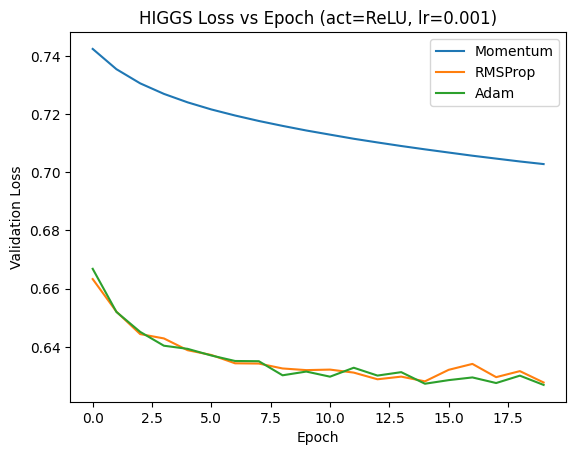

In [24]:
import matplotlib.pyplot as plt

def run_higgs_optimizer_compare(hidden_act=ReLU, lr=0.001, epochs=20):
    configs = [
        ("Momentum", Momentum(lr=lr, beta=0.9)),
        ("RMSProp",  RMSProp(lr=lr, beta=0.9)),
        ("Adam",     Adam(lr=lr))
    ]

    histories = {}
    for name, opt in configs:
        print("\n====================")
        print("HIGGS ->", name, "| act:", hidden_act.__name__, "| lr:", lr)
        print("====================")

        model = MLPBinary(
            layer_sizes=[28, 64, 32, 1],   # 2 hidden layer örneği
            hidden_activation=hidden_act,
            init="he" if hidden_act==ReLU else "xavier",
            seed=42
        )

        hist = train_mlp(
            model, X_h_train, y_h_train, X_h_val, y_h_val,
            optimizer=opt, epochs=epochs, batch_size=256
        )
        histories[name] = hist

    # tek grafikte val_loss
    plt.figure()
    for name in histories:
        plt.plot(histories[name]["val_loss"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"HIGGS Loss vs Epoch (act={hidden_act.__name__}, lr={lr})")
    plt.legend()
    plt.show()

    return histories

histories = run_higgs_optimizer_compare(hidden_act=ReLU, lr=0.001, epochs=20)



HIGGS -> Adam | act: ReLU | lr: 0.001
Epoch 1/20  train_loss=0.6631  val_loss=0.6668
Epoch 2/20  train_loss=0.6432  val_loss=0.6520
Epoch 3/20  train_loss=0.6315  val_loss=0.6452
Epoch 4/20  train_loss=0.6227  val_loss=0.6404
Epoch 5/20  train_loss=0.6167  val_loss=0.6393
Epoch 6/20  train_loss=0.6107  val_loss=0.6370
Epoch 7/20  train_loss=0.6080  val_loss=0.6352
Epoch 8/20  train_loss=0.6000  val_loss=0.6351
Epoch 9/20  train_loss=0.5953  val_loss=0.6302
Epoch 10/20  train_loss=0.5918  val_loss=0.6315
Epoch 11/20  train_loss=0.5869  val_loss=0.6298
Epoch 12/20  train_loss=0.5840  val_loss=0.6328
Epoch 13/20  train_loss=0.5795  val_loss=0.6302
Epoch 14/20  train_loss=0.5764  val_loss=0.6313
Epoch 15/20  train_loss=0.5731  val_loss=0.6273
Epoch 16/20  train_loss=0.5702  val_loss=0.6286
Epoch 17/20  train_loss=0.5658  val_loss=0.6295
Epoch 18/20  train_loss=0.5624  val_loss=0.6276
Epoch 19/20  train_loss=0.5600  val_loss=0.6301
Epoch 20/20  train_loss=0.5562  val_loss=0.6269

HIGGS -> 

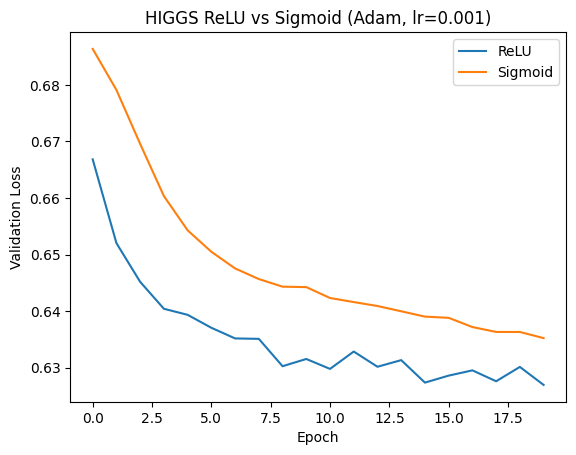

In [26]:
import matplotlib.pyplot as plt

def compare_relu_vs_sigmoid(lr=0.001, epochs=20):
    results = {}
    for act in [ReLU, Sigmoid]:
        print("\n====================")
        print("HIGGS -> Adam | act:", act.__name__, "| lr:", lr)
        print("====================")

        model = MLPBinary(
            layer_sizes=[28, 64, 32, 1],
            hidden_activation=act,
            init="he" if act==ReLU else "xavier",
            seed=42
        )

        hist = train_mlp(
            model, X_h_train, y_h_train, X_h_val, y_h_val,
            optimizer=Adam(lr=lr), epochs=epochs, batch_size=256
        )
        results[act.__name__] = hist

    plt.figure()
    for k in results:
        plt.plot(results[k]["val_loss"], label=k)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"HIGGS ReLU vs Sigmoid (Adam, lr={lr})")
    plt.legend()
    plt.show()

    return results

act_results = compare_relu_vs_sigmoid(lr=0.001, epochs=20)




HIGGS -> Adam | ReLU | lr: 0.1
Epoch 1/20  train_loss=0.6445  val_loss=0.6605
Epoch 2/20  train_loss=0.6393  val_loss=0.6659
Epoch 3/20  train_loss=0.6259  val_loss=0.6416
Epoch 4/20  train_loss=0.6019  val_loss=0.6256
Epoch 5/20  train_loss=0.6063  val_loss=0.6341
Epoch 6/20  train_loss=0.6068  val_loss=0.6391
Epoch 7/20  train_loss=0.5818  val_loss=0.6117
Epoch 8/20  train_loss=0.5877  val_loss=0.6114
Epoch 9/20  train_loss=0.5878  val_loss=0.6482
Epoch 10/20  train_loss=0.5730  val_loss=0.6221
Epoch 11/20  train_loss=0.5667  val_loss=0.6295
Epoch 12/20  train_loss=0.5917  val_loss=0.6367
Epoch 13/20  train_loss=0.5649  val_loss=0.6318
Epoch 14/20  train_loss=0.6282  val_loss=0.6540
Epoch 15/20  train_loss=0.6503  val_loss=0.6629
Epoch 16/20  train_loss=0.5793  val_loss=0.6367
Epoch 17/20  train_loss=0.5525  val_loss=0.6305
Epoch 18/20  train_loss=0.5951  val_loss=0.6397
Epoch 19/20  train_loss=0.5527  val_loss=0.6256
Epoch 20/20  train_loss=0.5451  val_loss=0.6226

HIGGS -> Adam | 

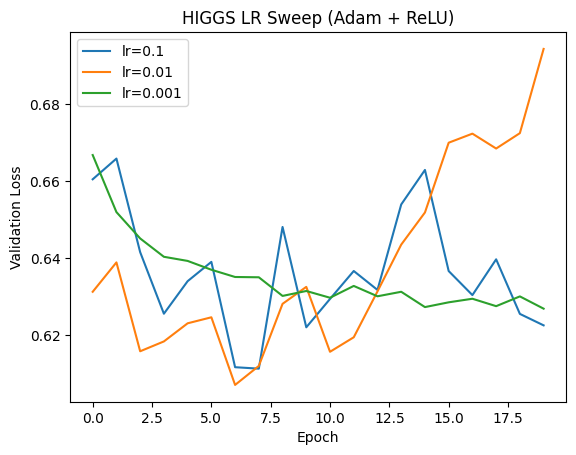

In [27]:
import matplotlib.pyplot as plt

def lr_sweep_adam_relu(lrs=[0.1, 0.01, 0.001], epochs=20):
    results = {}
    for lr in lrs:
        print("\n====================")
        print("HIGGS -> Adam | ReLU | lr:", lr)
        print("====================")

        model = MLPBinary(
            layer_sizes=[28, 64, 32, 1],
            hidden_activation=ReLU,
            init="he",
            seed=42
        )

        hist = train_mlp(
            model, X_h_train, y_h_train, X_h_val, y_h_val,
            optimizer=Adam(lr=lr), epochs=epochs, batch_size=256
        )
        results[str(lr)] = hist

    plt.figure()
    for lr in results:
        plt.plot(results[lr]["val_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("HIGGS LR Sweep (Adam + ReLU)")
    plt.legend()
    plt.show()

    return results

lr_results = lr_sweep_adam_relu(lrs=[0.1, 0.01, 0.001], epochs=20)


In [28]:
# 1) Train+Val birleştir (final eğitim için)
X_h_trfinal = np.vstack([X_h_train, X_h_val])
y_h_trfinal = np.concatenate([y_h_train, y_h_val])

# 2) Model yeniden kuruldu
mlp_higgs_final = MLPBinary(
    layer_sizes=[28, 64, 32, 1],
    hidden_activation=ReLU,
    init="he",
    seed=42
)

# 3) Eğitildi (validation yerine test'e bakmıyoruz; sadece loss görmek için val olarak X_h_val verilebilir ama şart değil)
hist_final = train_mlp(
    mlp_higgs_final,
    X_h_trfinal, y_h_trfinal,
    X_h_val, y_h_val,              # sadece log görmek için
    optimizer=Adam(lr=0.001),
    epochs=20,
    batch_size=256
)

# 4) Test tahmini
y_h_test_pred = mlp_higgs_final.predict(X_h_test).reshape(-1)
y_h_test_true = y_h_test.reshape(-1).astype(int)

acc, f1, cm = binary_metrics(y_h_test_true, y_h_test_pred)

print("\nHIGGS MLP (TEST)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


Epoch 1/20  train_loss=0.6586  val_loss=0.6579
Epoch 2/20  train_loss=0.6394  val_loss=0.6386
Epoch 3/20  train_loss=0.6291  val_loss=0.6289
Epoch 4/20  train_loss=0.6203  val_loss=0.6207
Epoch 5/20  train_loss=0.6136  val_loss=0.6141
Epoch 6/20  train_loss=0.6082  val_loss=0.6081
Epoch 7/20  train_loss=0.6036  val_loss=0.6062
Epoch 8/20  train_loss=0.5986  val_loss=0.6001
Epoch 9/20  train_loss=0.5940  val_loss=0.5953
Epoch 10/20  train_loss=0.5904  val_loss=0.5925
Epoch 11/20  train_loss=0.5868  val_loss=0.5892
Epoch 12/20  train_loss=0.5828  val_loss=0.5860
Epoch 13/20  train_loss=0.5791  val_loss=0.5806
Epoch 14/20  train_loss=0.5753  val_loss=0.5779
Epoch 15/20  train_loss=0.5721  val_loss=0.5737
Epoch 16/20  train_loss=0.5688  val_loss=0.5717
Epoch 17/20  train_loss=0.5655  val_loss=0.5692
Epoch 18/20  train_loss=0.5636  val_loss=0.5681
Epoch 19/20  train_loss=0.5590  val_loss=0.5612
Epoch 20/20  train_loss=0.5563  val_loss=0.5589

HIGGS MLP (TEST)
Accuracy: 0.6645
F1-score: 0.69

In [29]:
# Reuters model (input=10000)
mlp_reu = MLPBinary(
    layer_sizes=[10000, 128, 64, 1],   # Reuters daha zor -> biraz daha geniş
    hidden_activation=ReLU,
    init="he",
    seed=42
)

hist_reu = train_mlp(
    mlp_reu,
    X_reu_train_mlp, y_reu_train,
    X_reu_val_mlp, y_reu_val,
    optimizer=Adam(lr=0.001),
    epochs=10,          # Reuters dense biraz ağır, 10 epoch yeter
    batch_size=256
)

y_reu_test_pred = mlp_reu.predict(X_reu_test_mlp).reshape(-1)
acc, f1, cm = binary_metrics(y_reu_test.astype(int), y_reu_test_pred.astype(int))

print("\nREUTERS MLP (TEST)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


Epoch 1/10  train_loss=0.2488  val_loss=0.2646
Epoch 2/10  train_loss=0.1428  val_loss=0.1769
Epoch 3/10  train_loss=0.1011  val_loss=0.1727
Epoch 4/10  train_loss=0.0752  val_loss=0.1870
Epoch 5/10  train_loss=0.0596  val_loss=0.1996
Epoch 6/10  train_loss=0.0501  val_loss=0.2250
Epoch 7/10  train_loss=0.0420  val_loss=0.2424
Epoch 8/10  train_loss=0.0356  val_loss=0.2390
Epoch 9/10  train_loss=0.0311  val_loss=0.2566
Epoch 10/10  train_loss=0.0277  val_loss=0.2724

REUTERS MLP (TEST)
Accuracy: 0.9327693677649154
F1-score: 0.908761329305136
Confusion Matrix:
 [[1343   58]
 [  93  752]]


In [30]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# --- 1) Validation skorları---

# MLP score (olasılık)
mlp_val_score = mlp_higgs_final.predict_proba(X_h_val).reshape(-1)

# SVM score (decision function)
svm_val_score = svm_higgs.decision_function(X_h_val)

# Meta feature matrix
X_meta_val = np.column_stack([mlp_val_score, svm_val_score])
y_meta_val = y_h_val.astype(int)

print("Meta feature shape:", X_meta_val.shape)

# --- 2) Meta-model (Logistic Regression) ---
meta_clf = LogisticRegression()
meta_clf.fit(X_meta_val, y_meta_val)


Meta feature shape: (3200, 2)


LogisticRegression()

In [31]:
# Test skorları
mlp_test_score = mlp_higgs_final.predict_proba(X_h_test).reshape(-1)
svm_test_score = svm_higgs.decision_function(X_h_test)

X_meta_test = np.column_stack([mlp_test_score, svm_test_score])

y_meta_pred = meta_clf.predict(X_meta_test)

acc, f1, cm = binary_metrics(y_h_test.astype(int), y_meta_pred)

print("HIGGS STACKING (TEST)")
print("Accuracy:", acc)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)


HIGGS STACKING (TEST)
Accuracy: 0.66325
F1-score: 0.693794044100932
Confusion Matrix:
 [[1127  769]
 [ 578 1526]]
